In [1]:
import sys

import torch
from torch import nn
import numpy as np
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt

In [2]:
def predict_binary_pt(model, X, threshold=0.5):
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()
    return preds

def accuracy_pt(preds, Y):
    return (preds == Y).float().mean().item()

def precision_recall_binary_pt(preds, Y):
    preds = preds.flatten()
    Y = Y.flatten()

    tp = ((preds == 1) & (Y == 1)).sum().item()
    fp = ((preds == 1) & (Y == 0)).sum().item()
    fn = ((preds == 0) & (Y == 1)).sum().item()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall

def print_metrics_binary_pt(name, preds, Y):
    acc = accuracy_pt(preds, Y)
    prec, rec = precision_recall_binary_pt(preds, Y)
    print(f"{name} - Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")

def predict_multiclass_pt(model, X):
    with torch.no_grad():
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
    return preds

def accuracy_pt(preds, Y):
    return (preds == Y).float().mean().item()

def precision_recall_macro_pt(preds, Y, num_classes):
    """Macro-averaged precision/recall across all classes."""
    precisions, recalls = [], []
    for c in range(num_classes):
        tp = ((preds == c) & (Y == c)).sum().item()
        fp = ((preds == c) & (Y != c)).sum().item()
        fn = ((preds != c) & (Y == c)).sum().item()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precisions.append(precision)
        recalls.append(recall)
    return np.mean(precisions), np.mean(recalls)

def print_metrics_multi_pt(name, preds, Y, num_classes):
    acc = accuracy_pt(preds, Y)
    prec, rec = precision_recall_macro_pt(preds, Y, num_classes)
    print(f"{name} - Accuracy: {acc:.4f} | Macro Precision: {prec:.4f} | Macro Recall: {rec:.4f}")

In [3]:
train_images_processed_dir = "aptos2019/train_images_processed/train_images_processed"

train_binary = pd.read_csv("aptos2019/train_binary.csv")

X_train_binary = np.array([
    np.array(Image.open(os.path.join(train_images_processed_dir, f"{img_id}.png")))
        .astype(np.float32).flatten() / 255.0
    for img_id in train_binary["id_code"]
])
Y_train_binary = train_binary["diagnosis"].values
Y_train_binary = Y_train_binary.reshape(-1, 1)

X_train_binary_pt = torch.from_numpy(X_train_binary)  ## requires (samples, features)
Y_train_binary_pt = torch.from_numpy(Y_train_binary.astype(np.float32))  ## requires (samples, 1)

val_binary = pd.read_csv("aptos2019/valid_binary.csv")
val_images_processed_dir = "aptos2019/val_images_processed/val_images_processed"

X_val_binary = np.array([
    np.array(Image.open(os.path.join(val_images_processed_dir, f"{img_id}.png")))
        .astype(np.float32).flatten() / 255.0
    for img_id in val_binary["id_code"]
])
Y_val_binary = val_binary["diagnosis"].values
Y_val_binary = Y_val_binary.reshape(-1, 1)

X_val_binary_pt = torch.from_numpy(X_val_binary)  ## requires (samples, features)
Y_val_binary_pt = torch.from_numpy(Y_val_binary.astype(np.float32))  ## requires (samples, 1)

mean_binary = X_train_binary_pt.mean(dim=0, keepdim=True)
std_binary = X_train_binary_pt.std(dim=0, keepdim=True)

X_train_binary_std = (X_train_binary_pt - mean_binary) / (std_binary + 1e-8)
X_val_binary_std = (X_val_binary_pt - mean_binary) / (std_binary + 1e-8)

test_binary = pd.read_csv("aptos2019/test_binary.csv")
test_images_processed_dir = "aptos2019/test_images_processed/test_images_processed"

X_test_binary = np.array([
    np.array(Image.open(os.path.join(test_images_processed_dir, f"{img_id}.png")))
        .astype(np.float32).flatten() / 255.0
    for img_id in test_binary["id_code"]
])
Y_test_binary = test_binary["diagnosis"].values
Y_test_binary = Y_test_binary.reshape(-1, 1)

X_test_binary_pt = torch.from_numpy(X_test_binary)
Y_test_binary_pt = torch.from_numpy(Y_test_binary.astype(np.float32))

X_test_binary_std = (X_test_binary_pt - mean_binary) / (std_binary + 1e-8)

In [4]:
X = X_train_binary_std
Y = Y_train_binary_pt

n_features = X.shape[1]
model_binary = nn.Sequential(nn.Linear(n_features, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))  ## n_features -> 128 -> 64 -> 1
loss_fn_binary = nn.BCEWithLogitsLoss()  ## loss function will be calculated with logits

optimizer_binary = torch.optim.AdamW(model_binary.parameters(), lr=0.0001, weight_decay=1e-4)
num_epochs = 200

val_losses_binary = []
best_val_loss = float("inf")
best_epoch_binary = -1
checkpoint_path_binary = "best_model_binary_nn.pt"

for epoch in range(num_epochs):
    model_binary.train()
    logits = model_binary(X)
    loss = loss_fn_binary(logits, Y)

    optimizer_binary.zero_grad()
    loss.backward()
    optimizer_binary.step()

    model_binary.eval()
    with torch.no_grad():
        val_logits = model_binary(X_val_binary_std)
        val_loss = loss_fn_binary(val_logits, Y_val_binary_pt)
    val_losses_binary.append(val_loss.item())
    model_binary.train()

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_epoch_binary = epoch
        torch.save(model_binary.state_dict(), checkpoint_path_binary)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.6f} | val_loss = {val_loss.item():.6f}")

print(f"\nBest epoch: {best_epoch_binary} | Best val loss: {best_val_loss:.6f}")

model_binary.load_state_dict(torch.load(checkpoint_path_binary))

train_preds_binary = predict_binary_pt(model_binary, X_train_binary_std)
val_preds_binary = predict_binary_pt(model_binary, X_val_binary_std)

print_metrics_binary_pt("Train", train_preds_binary, Y_train_binary_pt)
print_metrics_binary_pt("Val  ", val_preds_binary, Y_val_binary_pt)

Epoch 0: loss = 0.700703 | val_loss = 0.819620
Epoch 10: loss = 0.225725 | val_loss = 0.218564
Epoch 20: loss = 0.167528 | val_loss = 0.185164
Epoch 30: loss = 0.127255 | val_loss = 0.166834
Epoch 40: loss = 0.102205 | val_loss = 0.155457
Epoch 50: loss = 0.084373 | val_loss = 0.148444
Epoch 60: loss = 0.071221 | val_loss = 0.145044
Epoch 70: loss = 0.061332 | val_loss = 0.144404
Epoch 80: loss = 0.053468 | val_loss = 0.143306
Epoch 90: loss = 0.047076 | val_loss = 0.145029
Epoch 100: loss = 0.041561 | val_loss = 0.146402
Epoch 110: loss = 0.036782 | val_loss = 0.148840
Epoch 120: loss = 0.032525 | val_loss = 0.150511
Epoch 130: loss = 0.028739 | val_loss = 0.152618
Epoch 140: loss = 0.025462 | val_loss = 0.155316
Epoch 150: loss = 0.022596 | val_loss = 0.157722
Epoch 160: loss = 0.020057 | val_loss = 0.160445
Epoch 170: loss = 0.017850 | val_loss = 0.163369
Epoch 180: loss = 0.015953 | val_loss = 0.165589
Epoch 190: loss = 0.014299 | val_loss = 0.167566

Best epoch: 80 | Best val loss

In [5]:
train_multi = pd.read_csv("aptos2019/train_multiclass.csv")

X_train_multi = np.array([
    np.array(Image.open(os.path.join(train_images_processed_dir, f"{img_id}.png")))
        .astype(np.float32).flatten() / 255.0
    for img_id in train_multi["id_code"]
])
Y_train_multi = train_multi["diagnosis"].values

X_train_multi_pt = torch.from_numpy(X_train_multi)  ## (samples, features)
Y_train_multi_pt = torch.from_numpy(Y_train_multi.astype(np.int64))  ## (samples, 1)

val_multi = pd.read_csv("aptos2019/valid_multiclass.csv")
val_images_processed_dir = "aptos2019/val_images_processed/val_images_processed"

X_val_multi = np.array([
    np.array(Image.open(os.path.join(val_images_processed_dir, f"{img_id}.png")))
        .astype(np.float32).flatten() / 255.0
    for img_id in val_multi["id_code"]
])
Y_val_multi = val_multi["diagnosis"].values

X_val_multi_pt = torch.from_numpy(X_val_multi)
Y_val_multi_pt = torch.from_numpy(Y_val_multi.astype(np.int64))

mean_multi = X_train_multi_pt.mean(dim=0, keepdim=True)
std_multi = X_train_multi_pt.std(dim=0, keepdim=True)

X_train_multi_std = (X_train_multi_pt - mean_multi) / (std_multi + 1e-8)
X_val_multi_std = (X_val_multi_pt - mean_multi) / (std_multi + 1e-8)

test_multi = pd.read_csv("aptos2019/test_multiclass.csv")
test_images_processed_dir = "aptos2019/test_images_processed/test_images_processed"

X_test_multi = np.array([
    np.array(Image.open(os.path.join(test_images_processed_dir, f"{img_id}.png")))
        .astype(np.float32).flatten() / 255.0
    for img_id in test_multi["id_code"]
])
Y_test_multi = test_multi["diagnosis"].values

X_test_multi_pt = torch.from_numpy(X_test_multi)
Y_test_multi_pt = torch.from_numpy(Y_test_multi.astype(np.int64))

X_test_multi_std = (X_test_multi_pt - mean_multi) / (std_multi + 1e-8)

In [6]:
X = X_train_multi_std
Y = Y_train_multi_pt

n_features = X.shape[1]
num_classes = 4
model_multi = nn.Sequential(
    nn.Linear(n_features, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 4)
)

class_counts = np.bincount(Y_train_multi, minlength=num_classes)
class_weights = torch.tensor(1.0 / np.sqrt(class_counts), dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * num_classes

loss_fn_multi = nn.CrossEntropyLoss(weight=class_weights)

optimizer_multi = torch.optim.AdamW(model_multi.parameters(), lr=0.00001, weight_decay=1e-4)
num_epochs = 200

val_losses_multi = []
best_val_loss = float("inf")
best_epoch_multi = -1
checkpoint_path_multi = "best_model_multiclass_nn.pt"

for epoch in range(num_epochs):
    model_multi.train()
    logits = model_multi(X)
    loss = loss_fn_multi(logits, Y)

    optimizer_multi.zero_grad()
    loss.backward()
    optimizer_multi.step()

    model_multi.eval()
    with torch.no_grad():
        val_logits = model_multi(X_val_multi_std)
        val_loss = loss_fn_multi(val_logits, Y_val_multi_pt)
    val_losses_multi.append(val_loss.item())
    model_multi.train()

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_epoch_multi = epoch
        torch.save(model_multi.state_dict(), checkpoint_path_multi)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.6f} | val_loss = {val_loss.item():.6f}")

print(f"\nBest epoch: {best_epoch_multi} | Best val loss: {best_val_loss:.6f}")

model_multi.load_state_dict(torch.load(checkpoint_path_multi))

train_preds_multi = predict_multiclass_pt(model_multi, X_train_multi_std)
val_preds_multi = predict_multiclass_pt(model_multi, X_val_multi_std)

print_metrics_multi_pt("Train", train_preds_multi, Y_train_multi_pt, num_classes)
print_metrics_multi_pt("Val  ", val_preds_multi, Y_val_multi_pt, num_classes)

Epoch 0: loss = 1.399902 | val_loss = 1.358826
Epoch 10: loss = 1.150173 | val_loss = 1.241969
Epoch 20: loss = 1.033804 | val_loss = 1.211291
Epoch 30: loss = 0.942744 | val_loss = 1.197458
Epoch 40: loss = 0.865515 | val_loss = 1.199395
Epoch 50: loss = 0.797977 | val_loss = 1.201869
Epoch 60: loss = 0.738051 | val_loss = 1.209862
Epoch 70: loss = 0.684094 | val_loss = 1.215121
Epoch 80: loss = 0.635155 | val_loss = 1.225898
Epoch 90: loss = 0.590414 | val_loss = 1.237974
Epoch 100: loss = 0.549413 | val_loss = 1.249380
Epoch 110: loss = 0.511879 | val_loss = 1.262008
Epoch 120: loss = 0.477540 | val_loss = 1.276103
Epoch 130: loss = 0.445953 | val_loss = 1.289109
Epoch 140: loss = 0.416849 | val_loss = 1.304617
Epoch 150: loss = 0.389953 | val_loss = 1.319012
Epoch 160: loss = 0.365046 | val_loss = 1.335604
Epoch 170: loss = 0.341912 | val_loss = 1.352105
Epoch 180: loss = 0.320501 | val_loss = 1.368573
Epoch 190: loss = 0.300776 | val_loss = 1.385273

Best epoch: 31 | Best val loss

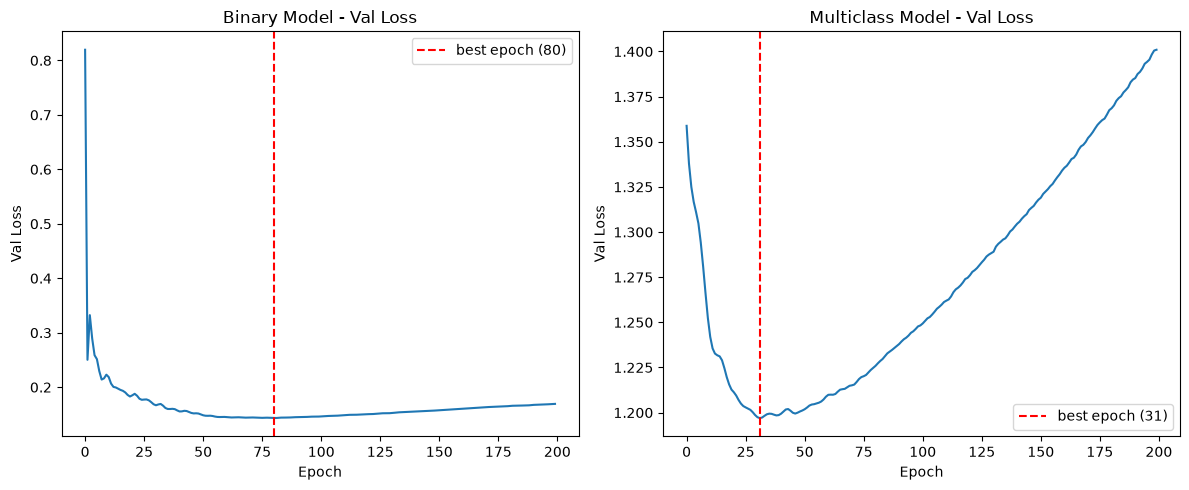

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(val_losses_binary)
axes[0].axvline(best_epoch_binary, color="red", linestyle="--", label=f"best epoch ({best_epoch_binary})")
axes[0].set_title("Binary Model - Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Loss")
axes[0].legend()

axes[1].plot(val_losses_multi)
axes[1].axvline(best_epoch_multi, color="red", linestyle="--", label=f"best epoch ({best_epoch_multi})")
axes[1].set_title("Multiclass Model - Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
model_binary.load_state_dict(torch.load(checkpoint_path_binary))

test_preds_binary = predict_binary_pt(model_binary, X_test_binary_std)
print_metrics_binary_pt("Test ", test_preds_binary, Y_test_binary_pt)

Test  - Accuracy: 0.9563 | Precision: 0.9415 | Recall: 0.9641


In [9]:
model_multi.load_state_dict(torch.load(checkpoint_path_multi))

test_preds_multi = predict_multiclass_pt(model_multi, X_test_multi_std)
print_metrics_multi_pt("Test ", test_preds_multi, Y_test_multi_pt, num_classes)

Test  - Accuracy: 0.4850 | Macro Precision: 0.3997 | Macro Recall: 0.3697
